Task 1

1(a)

Sample mean : 0.019458202211035957 (true = 0)
Sample std dev : 1.492800873875773 (true = 1.414214)


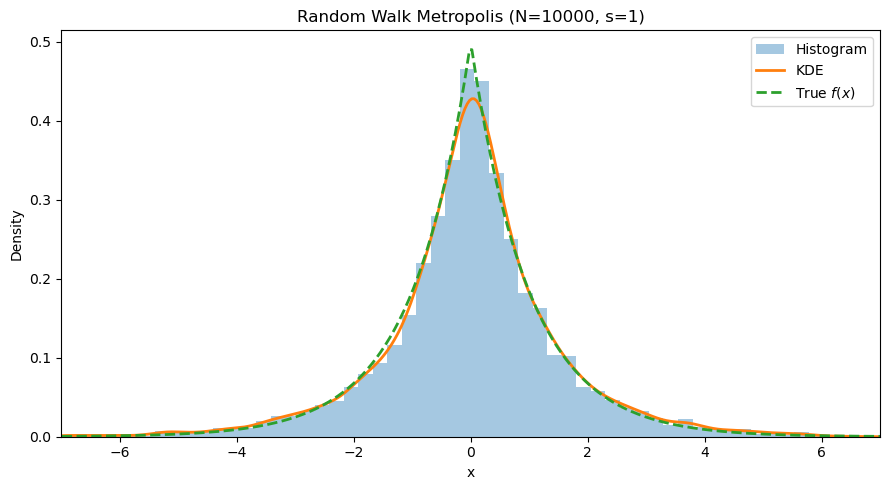

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import math

def log_f(x):
    return np.log(0.5 * math.exp(-np.abs(x)))


def random_walk_metropolis(N, s, x0, seed):
    rng = np.random.default_rng(seed)
    samples = np.empty(N + 1)
    samples[0] = x0

    for i in range(1, N + 1):
        x_star = rng.normal(loc=samples[i - 1], scale=s)
        log_r  = log_f(x_star) - log_f(samples[i - 1])
        log_u  = np.log(rng.uniform())
        if log_u < log_r:
            samples[i] = x_star
        else:
            samples[i] = samples[i - 1]
    return samples[1:]


samples = random_walk_metropolis(10000, 1.0, 0, 42)

print(f"Sample mean : {np.mean(samples)} (true = 0)")
print(f"Sample std dev : {np.std(samples, ddof=1)} (true = {np.sqrt(2):.6f})")

fig, ax = plt.subplots(figsize=(9, 5))
x = np.linspace(-8, 8, 400)
ax.hist(samples, bins=60, density=True, alpha=0.4, label="Histogram")
ax.plot(x, gaussian_kde(samples)(x), lw=2, label="KDE")
ax.plot(x, 0.5 * np.exp(-np.abs(x)), "--", lw=2, label=r"True $f(x)$")
ax.set(xlabel="x", ylabel="Density", title="Random Walk Metropolis (N=10000, s=1)", xlim=(-7, 7),)
ax.legend()
plt.tight_layout()
plt.show()

1(b)

R-hat at s=0.001 : 99.751679


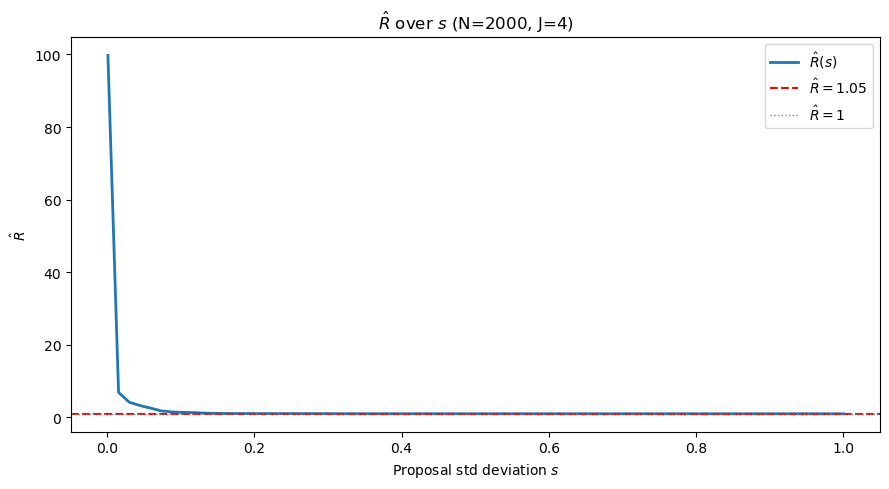


  R-hat < 1.05 for s [0.204, 1.000]


In [3]:
def rhat_f(chains):
    J = len(chains)
    means = np.array([np.mean(c) for c in chains])
    vars_ = np.array([np.mean((c - m)**2) for c, m in zip(chains, means)])

    W = np.mean(vars_)
    M = np.mean(means)
    B = np.mean((means - M)**2)

    return np.sqrt((B + W) / W)

x0_vals = [-2.0, -1.0, 1.0, 2.0]
chains = [random_walk_metropolis(2000, 0.001, x0=x0_vals[j], seed=100 + j)for j in range(4)]
print(f"R-hat at s=0.001 : {rhat_f(chains):.6f}")

s_grid = np.linspace(0.001, 1.0, 70)
rhat_vals = []
for s_val in s_grid:
    chains_1 = [random_walk_metropolis(2000, s_val, x0=x0_vals[j], seed=100 + j) for j in range(4)]
    rhat_vals.append(rhat_f(chains_1))
rhat_vals = np.array(rhat_vals)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(s_grid, rhat_vals, lw=2, label=r"$\hat{R}(s)$")
ax.axhline(1.05, ls="--", color = "red", lw=1.5, label = r"$\hat{R}=1.05$")
ax.axhline(1.00, ls=":",  color = "grey", lw=1.0, label = r"$\hat{R}=1$")
ax.set(xlabel="Proposal std deviation $s$", ylabel = r"$\hat{R}$", title=r"$\hat{R}$ over $s$ (N=2000, J=4)",)
ax.legend()
plt.tight_layout()
plt.show()

good_s = s_grid[rhat_vals < 1.05]
print(f"\n  R-hat < 1.05 for s [{good_s.min():.3f}, {good_s.max():.3f}]")